In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

---

---

# LOSSES COMPARISON

In [6]:
def plot_losses(loss_data):
    # Unwrap the dictionary if it's stored inside a NumPy 0D array
    if isinstance(loss_data, np.ndarray):
        loss_data = loss_data.item()

    # Determine epochs starting from 1 up to N
    num_epochs = len(loss_data['train_loss'])
    epochs = range(1, num_epochs + 1)

    # Setup figure
    plt.figure(figsize=(8, 5))

    # Plot each loss metric
    plt.plot(epochs, loss_data['train_loss'], label='Train Loss', marker='o')
    plt.plot(epochs, loss_data['val_loss'], label='Validation Loss', marker='s')
    plt.plot(epochs, loss_data['test_loss'], label='Test Loss', marker='^')

    # Formatting
    plt.title('Training, Validation, and Test Loss over Epochs', fontsize=12, fontweight='bold')
    plt.xlabel('Epoch', fontsize=11)
    plt.ylabel('Loss', fontsize=11)
    plt.xticks(epochs)  # Show integer ticks for all epochs
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(frameon=True)
    plt.tight_layout()

    plt.show()

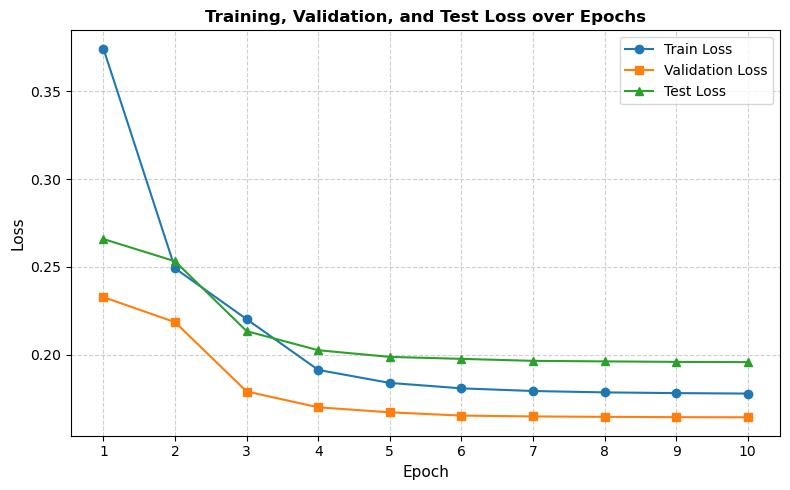

In [8]:
losses = np.load("./checkpoints/sl96_pl96_dm64_el2_tk5/loss_history.npy", allow_pickle=True)

plot_losses(losses)

---

# PREDICTION EXAMPLES

In [47]:
def plot_prediction(sample_input, sample_true, sample_pred, save_path, save=True, channel=0, sample_idx=0 ):
    """
    Plot TimesNet-style forecasting results.

    Args:
        sample_input: [N, seq_len, C]
        sample_true:  [N, pred_len, C]
        sample_pred:  [N, pred_len, C]
        channel: which variable (0..320)
        sample_idx: which sample in batch
    """

    # -------------------------------------------------------
    # Extract single series
    # -------------------------------------------------------
    x_input = sample_input[sample_idx, :, channel]   # [seq_len]
    x_true  = sample_true[sample_idx, :, channel]    # [pred_len]
    x_pred  = sample_pred[sample_idx, :, channel]    # [pred_len]

    seq_len = len(x_input)
    pred_len = len(x_pred)

    # -------------------------------------------------------
    # TIME AXIS
    # -------------------------------------------------------
    # past: negative time
    # future: starts at 0
    # -------------------------------------------------------
    t_past = np.arange(-seq_len, 0)
    t_future = np.arange(0, pred_len)

    # full ground truth (past + future)
    full_true = np.concatenate([x_input, x_true])
    t_full = np.arange(-seq_len, pred_len)

    # -------------------------------------------------------
    # PLOT
    # -------------------------------------------------------
    plt.figure(figsize=(14, 6))

    # ground truth (past + future)
    plt.plot(
        t_full,
        full_true,
        color="gray",
        linewidth=2,
        label="Ground Truth"
    )

    # prediction (future only)
    plt.plot(
        t_future,
        x_pred,
        color="orange",
        linewidth=2,
        label="Prediction"
    )

    # vertical split at prediction start
    plt.axvline(x=0, color="black", linestyle="--", linewidth=1, alpha=0.3)

    # -------------------------------------------------------
    # STYLE
    # -------------------------------------------------------
    plt.title(f"Forecasting Result (channel {channel})")
    plt.xlabel("Time (t)")
    plt.ylabel("Electricity consumption (a.u.)")

    plt.legend()
    plt.grid(alpha=0.3)

    if save == True:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()

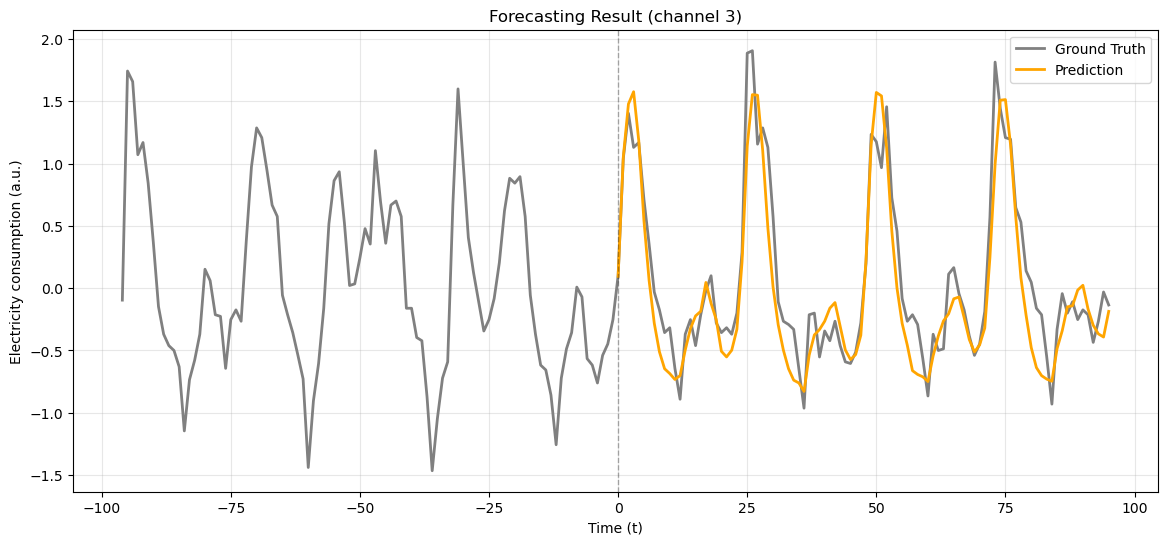

In [52]:
root_path = "checkpoints/sl96_pl96_dm64_el2_tk5/"

inputs = np.load(os.path.join(root_path, "sample_input.npy"))
trues = np.load(os.path.join(root_path, "sample_true.npy"))
preds = np.load(os.path.join(root_path, "sample_pred.npy"))
save_path = os.path.join(root_path, "prediction_example.png")

plot_prediction(inputs, trues, preds,save_path, save=True, channel=3, sample_idx=0)

In [56]:
# debug:
# min{max{2^ceil(log C) , d_min }, d_max } 
import math
C= 321
d_min = 32
d_max = 512
result = min(max(2 ** math.ceil(math.log2(C)), d_min), d_max)
result

512